In [1]:
# siibra is a Python library that provides programmatic access to human brain atlases—especially the Julich-Brain Atlas—enabling 
#querying, downloading, and visualization of brain regions, maps, and connectivity data from the EBRAINS platform. this cell 
#we just testing different functions of siibra
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go
from scipy.interpolate import LinearNDInterpolator

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.


In [20]:
STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) right")
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
STN_map = STN_R.get_regional_map(space, maptype="statistical")

In [21]:
NIfTI_STN_R = STN_map.fetch()

In [16]:
NIfTI_STN_R.affine

array([[   1.,    0.,    0.,  -96.],
       [   0.,    1.,    0., -132.],
       [   0.,    0.,    1.,  -78.],
       [   0.,    0.,    0.,    1.]])

In [17]:
# Get voxel data as a numpy array
STN_R_data = NIfTI_STN_R.get_fdata()

In [9]:
# Assuming STN_R_data is a 3D NumPy array
nonzero_indices = np.argwhere(STN_R_data > 0)             # Shape: (N, 3)
nonzero_values = STN_R_data[STN_R_data > 0]               # Shape: (N,)

# Combine indices and values into a single array: (x, y, z, value)
nonzero_voxels = np.hstack((nonzero_indices, nonzero_values[:, np.newaxis]))

In [10]:
nonzero_voxels[np.argmax(nonzero_voxels[:,3])]

array([101., 121.,  66.,   1.])

In [11]:
# Shift voxel coordinates directly (vectorized)
nonzero_voxels[:, 0] -= nonzero_voxels[np.argmax(nonzero_voxels[:,3])][0]  # X axis
nonzero_voxels[:, 1] -= nonzero_voxels[np.argmax(nonzero_voxels[:,3])][1]  # Y axis
nonzero_voxels[:, 2] -= nonzero_voxels[np.argmax(nonzero_voxels[:,3])][2]   # Z axis

# Print the transformed coordinates
print(nonzero_voxels[:, 0])  # X
print(nonzero_voxels[:, 1])  # Y
print(nonzero_voxels[:, 2])  # Z

[ 0.  0.  0.  0.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.
  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.  3.
  3.  3.  3.  3.  3.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.
  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.
  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  5.  5.  5.  5.
  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.
  5.  5.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.
  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.
  6.  6.  6.  6.  6.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.
  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7.  7

In [12]:
nonzero_voxels[np.argmax(nonzero_voxels[:,3])]

array([0., 0., 0., 1.])

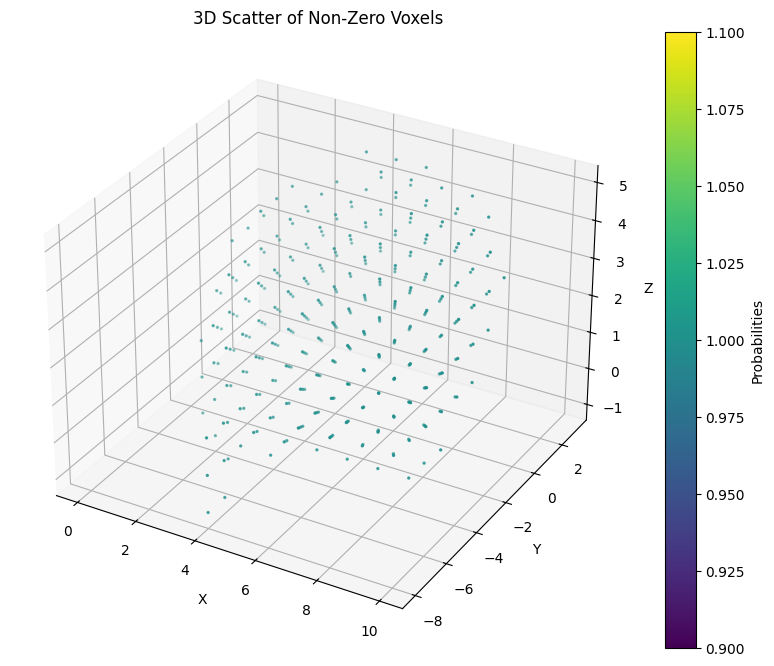

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Required for 3D plotting
%matplotlib inline
#%matplotlib widget

# Step 2: Plot as 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Split coordinates
x, y, z = nonzero_voxels[:, 0], nonzero_voxels[:, 1], nonzero_voxels[:, 2]

# Normalize values for color mapping
#norm_values = (nonzero_values - nonzero_values.min()) / (nonzero_values.ptp())

# Scatter plot
sc = ax.scatter(x, y, z, c=nonzero_values, cmap='viridis', s=2)

# Color bar
plt.colorbar(sc, ax=ax, label='Probabilities')

# Labels
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Scatter of Non-Zero Voxels')

plt.show()


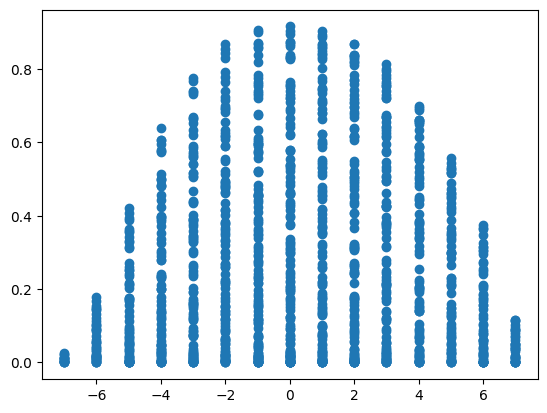

In [170]:
plt.scatter(y, nonzero_values)

In [189]:
from scipy.spatial import ConvexHull
hull = ConvexHull(nonzero_voxels[:, 0:3])

In [209]:
STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) right")
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
STN_map = STN_R.get_regional_map(space, maptype="statistical")
NIfTI_STN_R = STN_map.fetch()
STN_R_data = NIfTI_STN_R.get_fdata()
affine = NIfTI_STN_R.affine

In [253]:
# Flatten and mask out zero or invalid voxels
STN_R_data_flat = STN_R_data.flatten()
STN_R_data_valid_probs = voxel_flat[voxel_flat > 0]

STN_R_data_valid_probs /= STN_R_data_valid_probs.sum()  

## Get voxel indices (i,j,k) of valid voxels
STN_R_data_indices = np.argwhere(STN_R_data > 0)

# Shift voxel coordinates 
#STN_R_data_indices[:, 0] -= STN_R_data_indices[np.argmax(STN_R_data_valid_probs)][0] # X axis
#STN_R_data_indices[:, 1] -= STN_R_data_indices[np.argmax(STN_R_data_valid_probs)][1]  # Y axis
#STN_R_data_indices[:, 2] -= STN_R_data_indices[np.argmax(STN_R_data_valid_probs)][2]   # Z axis
print(STN_R_data_indices)

[[100 120  66]
 [100 120  67]
 [100 120  68]
 ...
 [113 120  71]
 [113 120  72]
 [113 121  71]]


In [274]:
def sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine, number_points):
    coordinates = np.zeros(shape=(number_points, 4))
    for i in range(0,number_points):
        index = np.random.choice(len(STN_R_data_valid_probs), p=STN_R_data_valid_probs)
        voxel_coord = STN_R_data_indices[index]

        # Add random offset in voxel space
        #offset = np.random.uniform(0, 1, size=3)
        #voxel_point = voxel_coord + offset

        # Convert to world coordinate
        voxel_coord = np.append(voxel_coord, 1)
        voxel_coord = affine @ voxel_coord
        coordinates[i] = voxel_coord

        
    return coordinates[:, 0:3]

In [261]:
def sample_points_interpolated(STN_R_data_valid_probs, STN_R_data_indices, affine, number_points):
    coordinates = np.zeros(shape=(number_points, 4))
    Vint = LinearNDInterpolator(STN_R_data_indices, STN_R_data_valid_probs)
    interpolated_probabilities = Vint(112.6, 121, 69.75)
    print(interpolated_probabilities)        
    return 

In [275]:
sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine,10)


array([[  8., -15., -14.],
       [  9., -14., -10.],
       [ 13., -17.,  -9.],
       [  9., -14., -10.],
       [ 12., -14.,  -8.],
       [  7., -11., -11.],
       [ 13., -13.,  -6.],
       [ 15., -17., -11.],
       [  6., -11., -13.],
       [  9., -14., -12.]])

In [273]:
np.arange(3)

array([0, 1, 2])

In [277]:
STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) right")
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
STN_map = STN_R.get_regional_map(space, maptype="statistical")
NIfTI_STN_R = STN_map.fetch()
STN_R_data = NIfTI_STN_R.get_fdata()
affine = NIfTI_STN_R.affine


# Flatten and mask out zero or invalid voxels
STN_R_data_flat = STN_R_data.flatten()
STN_R_data_valid_probs = voxel_flat[voxel_flat > 0]

#normalise the probabilities to work with random choice
STN_R_data_valid_probs /= STN_R_data_valid_probs.sum()  

## Get voxel indices (i,j,k) of valid voxels
STN_R_data_indices = np.argwhere(STN_R_data > 0)


#random points in voxels
def sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine, number_points):
    coordinates = np.zeros(shape=(number_points, 4))
    for i in range(0,number_points):
        index = np.random.choice(len(STN_R_data_valid_probs), p=STN_R_data_valid_probs)
        voxel_coord = STN_R_data_indices[index]

        # Add random offset in voxel space
        #offset = np.random.uniform(0, 1, size=3)
        #voxel_point = voxel_coord + offset

        # Convert to world coordinate
        voxel_coord = np.append(voxel_coord, 1)
        voxel_coord = affine @ voxel_coord
        coordinates[i] = voxel_coord

        
    return coordinates[:, 0:3]


sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine,10)


array([[ 14., -17.,  -9.],
       [ 11., -13., -13.],
       [  5.,  -9., -11.],
       [ 15., -15., -12.],
       [ 15., -17., -11.],
       [ 14., -12.,  -8.],
       [ 14., -12.,  -7.],
       [ 11., -18., -13.],
       [ 10., -17., -16.],
       [ 10., -15., -10.]])

In [5]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE

STN_R = siibra.get_region("JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1", "STN (Subthalamus) right")
space = STN_R.spaces.get("MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC")
STN_map = STN_R.get_regional_map(space, maptype="statistical")
NIfTI_STN_R = STN_map.fetch()
STN_R_data = NIfTI_STN_R.get_fdata()
affine = NIfTI_STN_R.affine


# Flatten and mask out zero or invalid voxels
STN_R_data_flat = STN_R_data.flatten()
STN_R_data_valid_probs = STN_R_data_flat[STN_R_data_flat > 0]

#normalise the probabilities to work with random choice
STN_R_data_valid_probs /= STN_R_data_valid_probs.sum()  

## Get voxel indices (i,j,k) of valid voxels
STN_R_data_indices = np.argwhere(STN_R_data > 0)


#random points in voxels
def sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine, number_points):
    coordinates = np.zeros(shape=(number_points, 4))
    for i in range(0,number_points):
        index = np.random.choice(len(STN_R_data_valid_probs), p=STN_R_data_valid_probs)
        voxel_coord = STN_R_data_indices[index]

        # Convert to world coordinate
        voxel_coord = np.append(voxel_coord, 1)
        voxel_coord = affine @ voxel_coord
        coordinates[i] = voxel_coord        
    return coordinates[:, 0:3]


sample_points_in_voxel(STN_R_data_valid_probs, STN_R_data_indices, affine,10)


array([[ 14., -16., -12.],
       [ 12., -10., -10.],
       [ 11., -11., -10.],
       [  9., -11., -10.],
       [ 11., -13., -10.],
       [  8., -12., -10.],
       [ 15., -16., -12.],
       [  8., -14., -14.],
       [ 11., -16.,  -9.],
       [ 13., -17., -10.]])